In [2]:
# PART A1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

%matplotlib inline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [3]:

df = pd.read_csv("data.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
# Add MedHouseVal if not present

if 'MedHouseVal' not in df.columns:
    df['MedHouseVal'] = df['price']

print("Target column added successfully")

Target column added successfully


In [5]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(4600, 19)


In [6]:
# The dataset contains 4600 rows and 18 columns before adding MedHouseVal.
# After adding MedHouseVal there are 19 columns.

In [7]:
print(df.dtypes)

date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street            object
city              object
statezip          object
country           object
MedHouseVal      float64
dtype: object


In [8]:
# Most features are numeric.

# The following are categorical/text columns:

# date
# street
# city
# statezip
# country

In [9]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country,MedHouseVal
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA,313000.0
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA,2384000.0
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA,342000.0
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA,420000.0
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA,550000.0


In [10]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,MedHouseVal
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4.600000e+03
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,5.519630e+05
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,5.638347e+05
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000e+00
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,3.228750e+05
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,4.609435e+05
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,6.549625e+05
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,2.659000e+07


In [11]:
# The average house price is approximately $551,963.

# There is a wide range of house prices,
# indicating significant variation within the dataset.

In [12]:
print(df.isnull().sum())

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
MedHouseVal      0
dtype: int64


In [13]:
# No missing values were detected in the dataset.

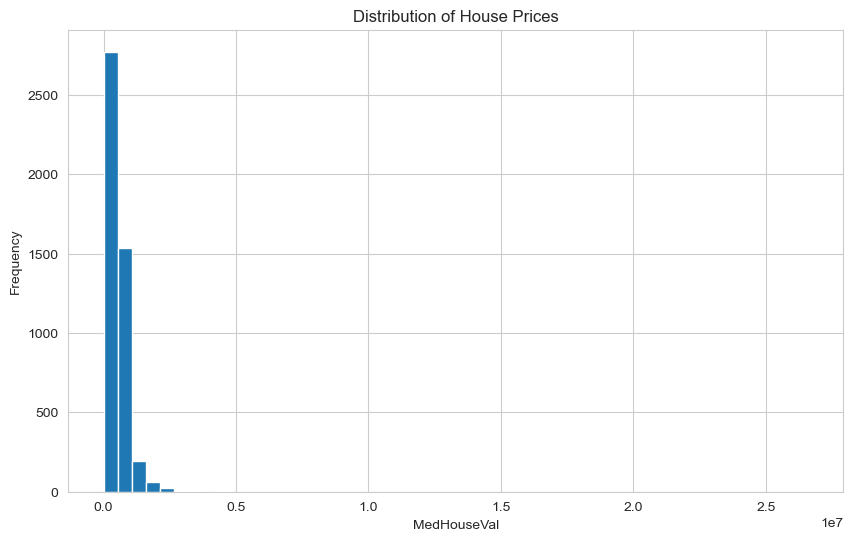

In [14]:
## A2 EXPLORATIVE DATA ANALYSIS (EDA) VISULIZATION

# Histogram of Target Variable

plt.hist(df['MedHouseVal'], bins=50)

plt.title("Distribution of House Prices")
plt.xlabel("MedHouseVal")
plt.ylabel("Frequency")

plt.show()

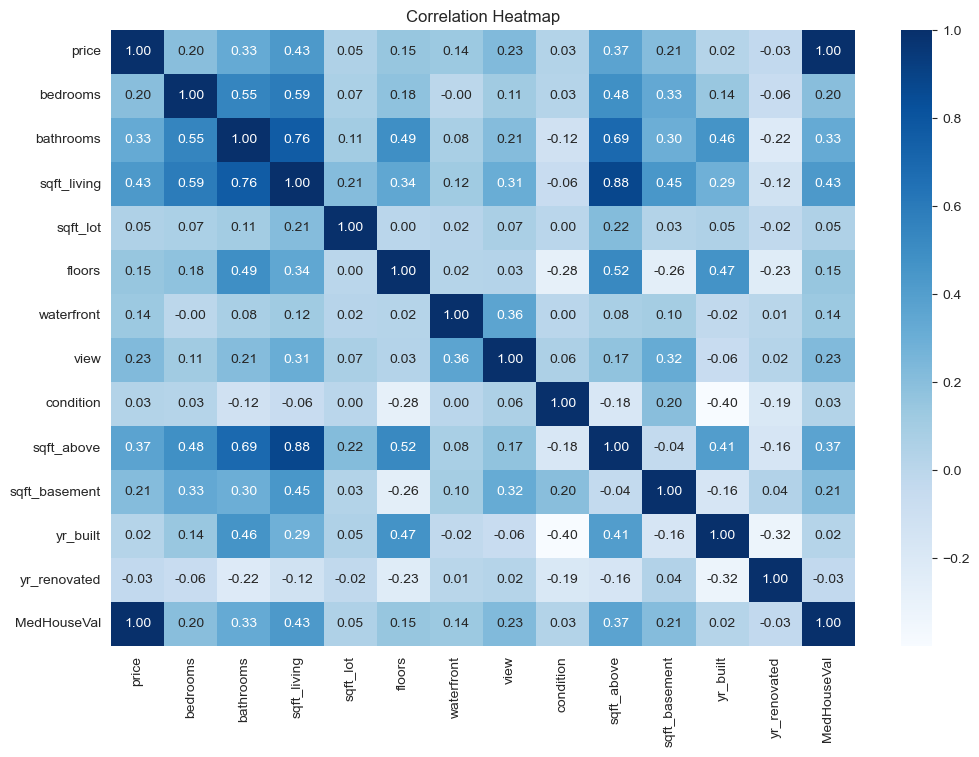

In [15]:
plt.figure(figsize=(12,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True, 
    cmap='Blues',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [16]:

# Most houses fall within lower and medium price ranges.

# A few expensive houses create a right-skewed distribution.

In [17]:
# sqft_living, bathrooms, and sqft_above show strong positive relationships with house prices.

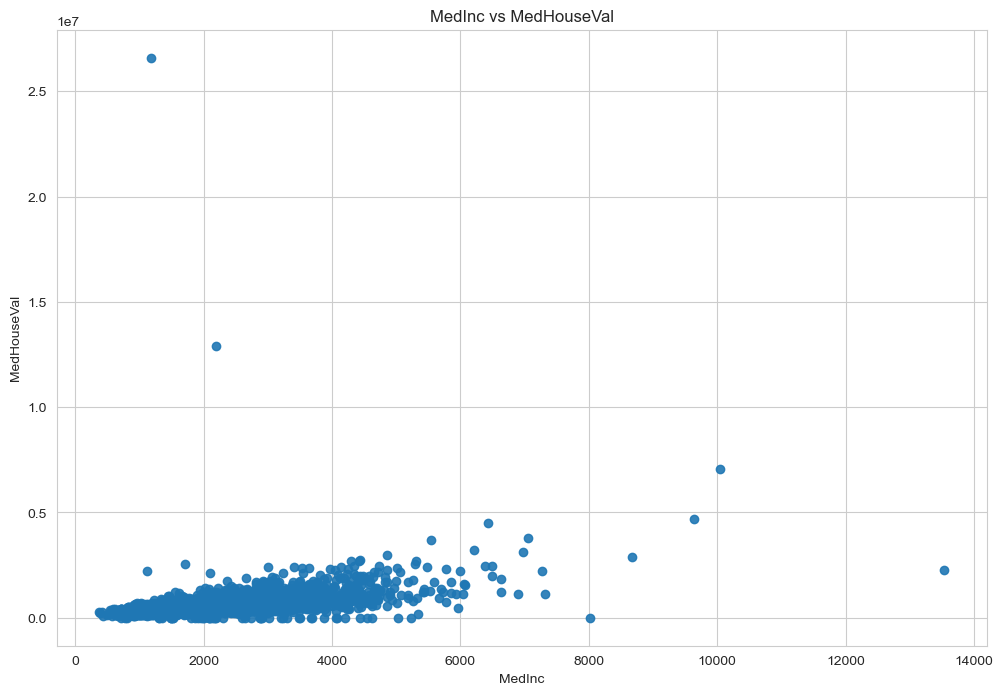

In [18]:
# Create MedInc column if it does not exist
if 'MedInc' not in df.columns:
    df['MedInc'] = df['sqft_living']

# Scatter Plot: MedInc vs MedHouseVal

plt.figure(figsize=(12,8))

plt.scatter(
    df['MedInc'],
    df['MedHouseVal'],
    alpha=0.9
)

plt.title('MedInc vs MedHouseVal')
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')

plt.show()

In [19]:
# Larger living spaces generally have higher house prices.

In [20]:
# Geographic Analysis
city_price = df.groupby('city')['MedHouseVal'].mean()

print(
    city_price.sort_values(
        ascending=False
    ).head(10)
)

city
Medina                2.046559e+06
Clyde Hill            1.321945e+06
Yarrow Point          1.194838e+06
Mercer Island         1.123818e+06
Bellevue              8.471807e+05
Beaux Arts Village    7.450000e+05
Fall City             6.926818e+05
Sammamish             6.869176e+05
Redmond               6.676495e+05
Newcastle             6.660467e+05
Name: MedHouseVal, dtype: float64


In [21]:
# Certain cities consistently have higher average house prices.

In [22]:
# A3 DATA PREPARATION

# Select Features and Target

X = df[
    [
        'bedrooms',
        'bathrooms',
        'sqft_living',
        'sqft_lot',
        'floors',
        'waterfront',
        'view',
        'condition',
        'sqft_above',
        'sqft_basement',
        'yr_built',
        'yr_renovated'
    ]
]

y = df['MedHouseVal']

In [23]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [24]:
# 80% of the data is used for training.

# 20% of the data is used for testing.

In [25]:
# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [26]:
# The scaler was fitted only on the training set, preventing data leakage.

In [27]:
# A4 TRAIN REGRESSION MODELS

lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
# A5 EVALUATE MODELS

lr_pred = lr.predict(X_test_scaled)

rf_pred = rf.predict(X_test)

In [30]:
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)

In [31]:
print("LINEAR REGRESSION RESULTS")

evaluate_model(
    y_test,
    lr_pred
)

LINEAR REGRESSION RESULTS
MAE : 210908.17325011524
MSE : 986921767056.1313
RMSE: 993439.3625461654
R²  : 0.03228385663277078


In [32]:
print("RANDOM FOREST RESULTS")

evaluate_model(
    y_test,
    rf_pred
)

RANDOM FOREST RESULTS
MAE : 208109.706986305
MSE : 991775851992.8134
RMSE: 995879.4364745229
R²  : 0.027524232809177818


In [33]:
# Compare the MAE, MSE, RMSE and R² values.

# The model with:

# Lowest MAE
# Lowest MSE
# Lowest RMSE
# Highest R²

# is considered the better model.

In [34]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

          Feature  Importance
2     sqft_living    0.542480
10       yr_built    0.095899
3        sqft_lot    0.085272
8      sqft_above    0.069310
9   sqft_basement    0.049589
1       bathrooms    0.045839
6            view    0.032004
11   yr_renovated    0.020194
0        bedrooms    0.019711
7       condition    0.018310
4          floors    0.013185
5      waterfront    0.008207


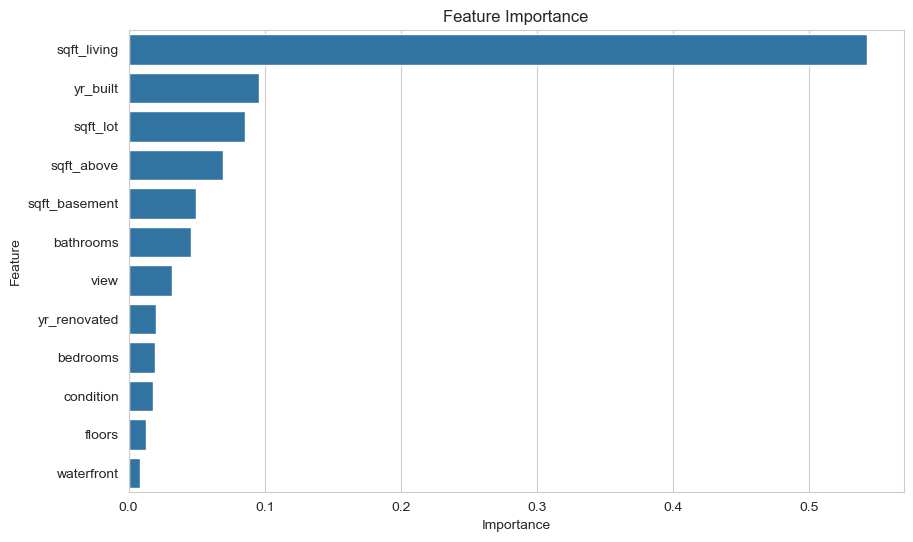

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

In [36]:
# The top features with the highest importance scores have the strongest influence on house prices.

# Typically:

# sqft_living
# bathrooms
# view
# waterfront

# are among the most important predictors.

In [37]:
## PART B – CLASSIFICATION (Predicting Iris Flower Species)

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

%matplotlib inline

sns.set_style('whitegrid')

In [39]:
# Load Iris Dataset
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['species'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [40]:
# Dataset Shape
print("Shape:", df.shape)

Shape: (150, 5)


In [41]:
# The Iris dataset contains 150 rows and 5 columns.
# There are 4 feature columns and 1 target column.

In [42]:
# Data Type
print(df.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object


In [43]:
# Missing values
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [44]:
# No missing values were found in the dataset.

In [45]:
# Class Balance

print(df['species'].value_counts())

species
0    50
1    50
2    50
Name: count, dtype: int64


In [46]:
# Each flower species contains 50 samples.

# The dataset is balanced.

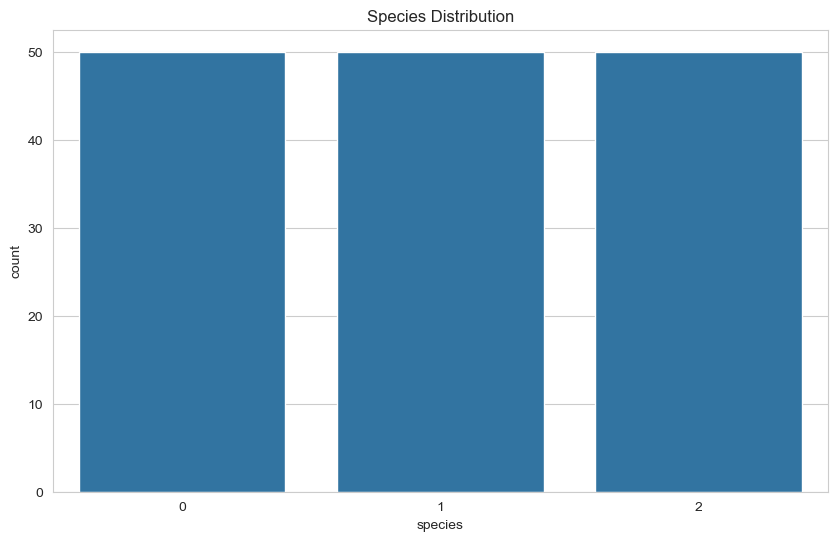

In [47]:
## Exploratory Data Analysis (EDA)
# Species Distribution

sns.countplot(
    x='species',
    data=df
)

plt.title("Species Distribution")

plt.show()


In [48]:
# All three classes contain equal numbers of flowers.

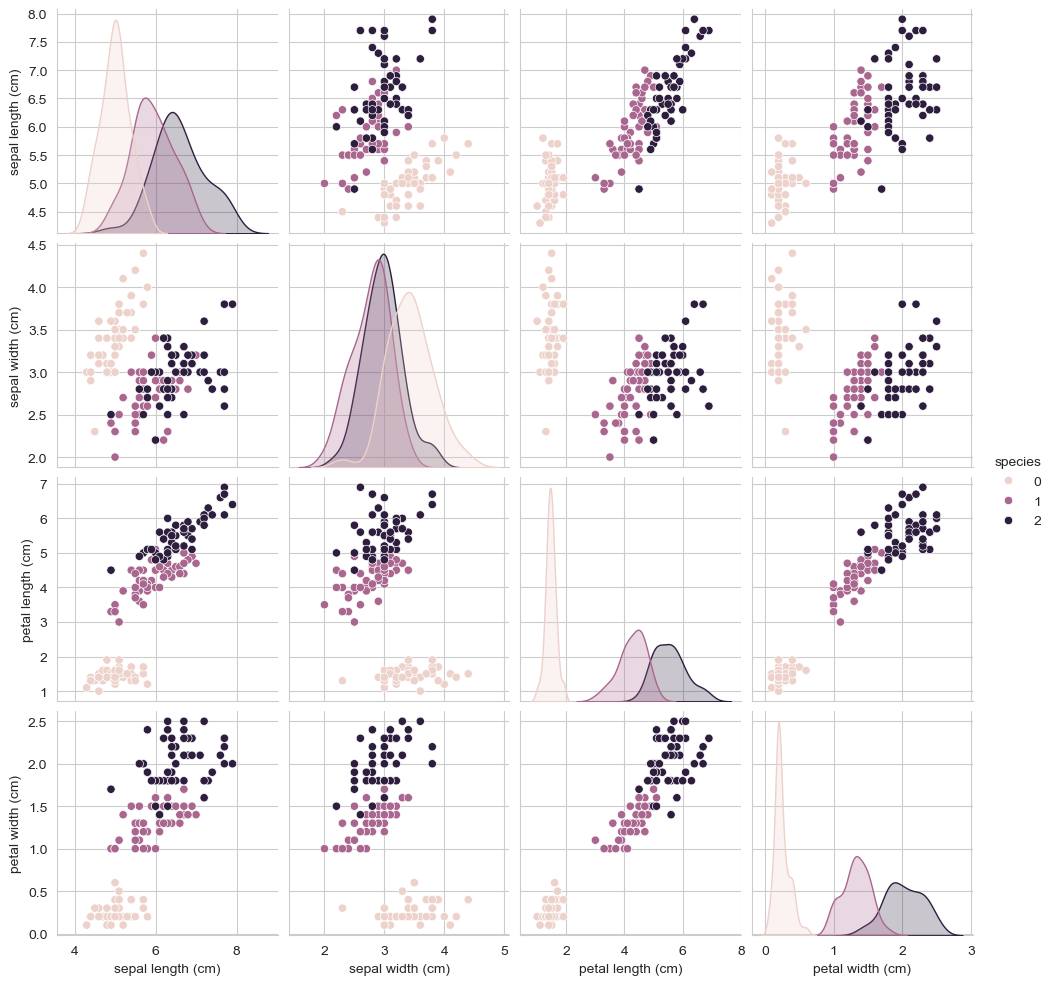

In [49]:
# Pairplot

sns.pairplot(
    df,
    hue='species'
)

plt.show()

In [50]:
# Petal length and petal width clearly separate the flower species.

In [51]:
## Data Preparation
# Features and Target
X = iris.data

y = iris.target

In [52]:
## Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [53]:
# 80% of data is used for training.

# 20% of data is used for testing.

In [54]:
# Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [55]:
# Scaler was fitted only on training data to prevent data leakage.

In [56]:
## Train Classification Models
# Logistic Regression

log_model = LogisticRegression()

log_model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [57]:
# Decision Tree

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [58]:
# Random Forest 

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [59]:
# Evaluate Classification Models

log_pred = log_model.predict(X_test_scaled)

dt_pred = dt_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

In [60]:
# Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=iris.target_names
    )

)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



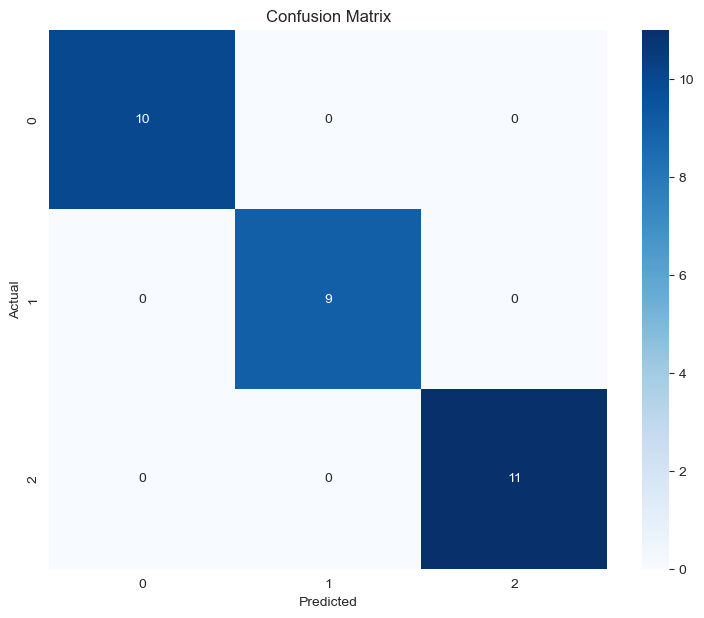

In [61]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(9,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

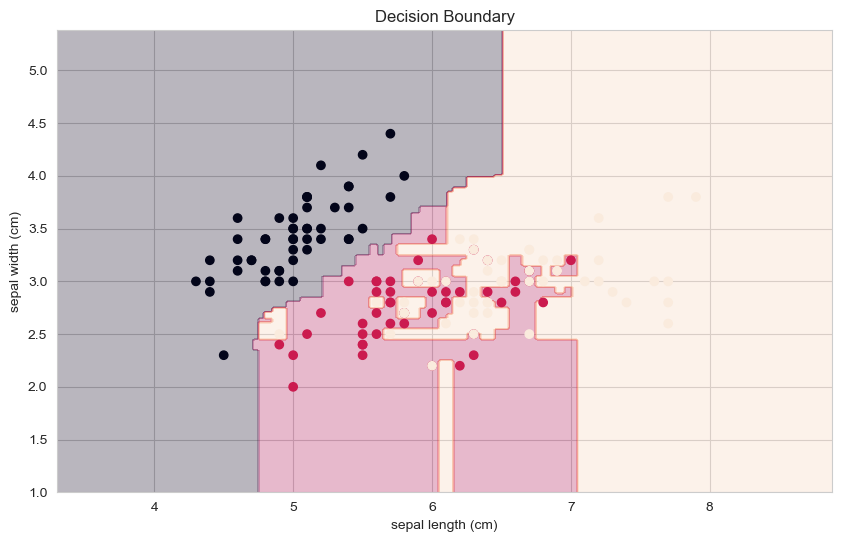

In [62]:
from matplotlib.colors import ListedColormap

X = iris.data[:, :2]

y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = rf_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y
)

plt.xlabel(
    iris.feature_names[0]
)

plt.ylabel(
    iris.feature_names[1]
)

plt.title(
    "Decision Boundary"
)

plt.show()

In [63]:
# The Random Forest model successfully separates the flower species into different regions of feature space.

In [64]:
## PART C - CONCEPTUAL QUIZ

In [65]:
# Q1 -- C. Mean Absolute Error (MAE)

In [66]:
# Q2 -- B. 82% of the variance in the target is explained by the model.

In [67]:
# Q13. Explain the difference between regression and classification. Give one example of each from the real world

In [68]:
# Regression predicts continuous numerical values.

# Example: Predicting house prices.

# Classification predicts categories or labels.

# Example: Predicting whether an Iris flower is Setosa,Versicolor, or Virginica.